# 03 — Dynamic Pricing Model

**Target:** `log_price`

**Models:** LinearRegression baseline + 3 GBM (CatBoost / LightGBM / XGBoost) + Optuna tuning + Ensemble + SHAP

**Input:** `data/processed/X_train.parquet`, ...
**Output:** trained models в `models/`

## Setup

In [43]:
# Базовые библиотеки и пути
import os, sys, time, json, pickle, warnings
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display

# sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting (3 разные библиотеки сравниваем)
import catboost as cb
import lightgbm as lgb
import xgboost as xgb
import optuna

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

# GPU
try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except ImportError:
    HAS_CUDA = False

SEED = 42
np.random.seed(SEED)

PROCESSED = Path("../data/processed")
MODELS    = Path("../models")
MODELS.mkdir(parents=True, exist_ok=True)

In [44]:
# Загружаем train/val/test
# Артефакты из nb02 уже содержат ТОЛЬКО строки с известной ценой (price.notna()).
X_tr  = pd.read_parquet(PROCESSED / "X_train.parquet")
X_val = pd.read_parquet(PROCESSED / "X_val.parquet")
X_te  = pd.read_parquet(PROCESSED / "X_test.parquet")
y_tr  = pd.read_parquet(PROCESSED / "y_train.parquet")["log_price"]
y_val = pd.read_parquet(PROCESSED / "y_val.parquet")["log_price"]
y_te  = pd.read_parquet(PROCESSED / "y_test.parquet")["log_price"]


# Категориальные колонки (object/bool) — нужны CatBoost (native) и LightGBM (category dtype).
# CatBoost не принимает NaN в категориях → заполняем "unknown".
CAT_COLS = X_tr.select_dtypes(include=["object", "bool"]).columns.tolist()
for df in (X_tr, X_val, X_te):
    for c in CAT_COLS:
        df[c] = df[c].fillna("unknown").astype(str)

print(f"train: {X_tr.shape}   val: {X_val.shape}   test: {X_te.shape}")
print(f"CUDA      : {HAS_CUDA}")
print(f"категории : {CAT_COLS}")


# Метрики (на оригинальной шкале price = exp(log_price) − 1)
def metrics(y_log_true, y_log_pred):
    """MAE / RMSE / RMSLE / R² на исходной шкале цены (евро)."""
    yt = np.expm1(y_log_true)
    yp = np.expm1(y_log_pred).clip(min=1)   # цена не может быть < 1€
    return pd.Series({
        "MAE":   mean_absolute_error(yt, yp),
        "RMSE":  np.sqrt(mean_squared_error(yt, yp)),
        "RMSLE": np.sqrt(mean_squared_error(np.log1p(yt), np.log1p(yp))),
        "R2":    r2_score(yt, yp),
    })


# Унифицированный отчёт по модели: шапка + метрики val/test одной таблицей.
def report_model(name, fit_time, device, y_val, pred_val, y_test, pred_test,
                 best_iter=None, extra=None):
    """Печатает результаты модели в едином формате (val + test)."""
    info = [f"fit: {fit_time:.2f}s", f"device: {device}"]
    if best_iter is not None: info.append(f"best_iter: {best_iter}")
    if extra:                 info.append(extra)
    print(f'\n[{name}]   " + "   '.join(info))
    print(f'  {"":6}{"MAE":>9}{"RMSE":>10}{"RMSLE":>9}{"R²":>9}')
    for split, yt, yp in [("val", y_val, pred_val), ("test", y_test, pred_test)]:
        m = metrics(yt, yp)
        print(f'  {split:<6}{m["MAE"]:>9.2f}{m["RMSE"]:>10.2f}'
              f'{m["RMSLE"]:>9.3f}{m["R2"]:>9.3f}')


train: (4090, 76)   val: (877, 76)   test: (877, 76)
CUDA      : True
категории : ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'instant_bookable', 'property_type_grp']


## Baseline: LinearRegression

- Fit на `log_price`
- Метрики: MAE / RMSE / RMSLE / R² на оригинальной шкале (через `np.expm1`)
- Кросс-валидация 5-fold для устойчивости

In [9]:
# LinearRegression — линейная регрессия (baseline = простейшая модель для отсчёта).
# Не работает с NaN и строками → нужен препроцессинг: one-hot для категорий,
# импутация (заполнение пропусков) медианой, StandardScaler (масштабирование).

# 1) One-hot encoding для категориальных
X_tr_lin  = pd.get_dummies(X_tr,  columns=CAT_COLS, drop_first=True)
X_val_lin = pd.get_dummies(X_val, columns=CAT_COLS, drop_first=True)
X_te_lin  = pd.get_dummies(X_te,  columns=CAT_COLS, drop_first=True)

# Выравниваем колонки (в val/test могут отсутствовать редкие категории)
X_val_lin = X_val_lin.reindex(columns=X_tr_lin.columns, fill_value=0)
X_te_lin  = X_te_lin.reindex(columns=X_tr_lin.columns,  fill_value=0)

# 2) Импутация медианой из train (важно: train-only, чтобы не было утечки)
medians  = X_tr_lin.median(numeric_only=True)
X_tr_lin  = X_tr_lin.fillna(medians)
X_val_lin = X_val_lin.fillna(medians)
X_te_lin  = X_te_lin.fillna(medians)

# 3) Масштабирование (нужно для линейных моделей)
scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr_lin)
X_val_s = scaler.transform(X_val_lin)
X_te_s  = scaler.transform(X_te_lin)

# 4) Обучаем + 5-fold CV (cross-validation) для устойчивости оценки
t0 = time.time()
lr = LinearRegression().fit(X_tr_s, y_tr)
lr_time = time.time() - t0
cv_mae = -cross_val_score(LinearRegression(), X_tr_s, y_tr,
                          scoring="neg_mean_absolute_error",
                          cv=KFold(5, shuffle=True, random_state=SEED)).mean()

lr_pred_val  = lr.predict(X_val_s)
lr_pred_test = lr.predict(X_te_s)

report_model("LinearRegression", lr_time, "CPU",
             y_val, lr_pred_val, y_te, lr_pred_test,
             extra=f"CV MAE (log): {cv_mae:.4f}")



[LinearRegression]   fit: 0.01s   device: CPU   CV MAE (log): 0.2393
              MAE      RMSE    RMSLE       R²
  val       66.81    121.09    0.307    0.429
  test      61.89    111.14    0.300    0.476


### Вывод baseline

Линейная регрессия выступает как базовая модель и задаёт отправную точку для сравнения. 

Модель показывает умеренное качество: `R² ≈ 0.43–0.48`, а ошибка остаётся довольно высокой (`MAE ≈ 62–67€`). 

Это говорит о том, что зависимость цены от признаков нелинейная, и простая линейная модель не может полностью уловить сложные паттерны рынка Airbnb.

При этом результат значительно лучше случайного предсказания, значит подготовленные фичи действительно содержат полезный сигнал. 

Далее ожидается, что GBM-модели (CatBoost, LightGBM, XGBoost) смогут лучше захватить нелинейные зависимости и заметно снизить ошибку прогноза.


## Three GBM Models

- CatBoost (нативные категориальные)
- LightGBM (скорость)
- XGBoost (точность)
- 5-fold CV с фиксированным seed
- early_stopping_rounds=50

In [10]:
# CatBoost — GBM (Gradient Boosting Machine) от Яндекса.
# Главная фишка: native поддержка категориальных колонок (передаём cat_features=).
# GPU: task_type="GPU" работает «из коробки» (не нужен OpenCL, как у LightGBM).

cat_params = {
    "iterations":           2000,
    "learning_rate":        0.05,
    "depth":                8,
    "l2_leaf_reg":          3.0,
    "random_seed":          SEED,
    "eval_metric":          "MAE",
    "early_stopping_rounds": 50,
    "verbose":              0,
    "task_type":            "GPU" if HAS_CUDA else "CPU",
}
cat_model = cb.CatBoostRegressor(**cat_params)

t0 = time.time()
cat_model.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    cat_features=CAT_COLS,
)
cat_time = time.time() - t0

cat_pred_val  = cat_model.predict(X_val)
cat_pred_test = cat_model.predict(X_te)

report_model("CatBoost", cat_time, cat_params["task_type"],
             y_val, cat_pred_val, y_te, cat_pred_test,
             best_iter=cat_model.get_best_iteration())


Default metric period is 5 because MAE is/are not implemented for GPU



[CatBoost]   fit: 73.82s   device: GPU   best_iter: 861
              MAE      RMSE    RMSLE       R²
  val       56.15     90.89    0.265    0.678
  test      53.57     87.31    0.268    0.677


In [11]:
# LightGBM — GBM от Microsoft, известен скоростью.
# Категориальные: ожидает dtype="category" (LightGBM сам их обработает).
# GPU: device="cuda" — CUDA-бэкенд (LightGBM >= 3.3.2, pip-версия поддерживает).
# Пробуем CUDA и автоматически падаем на CPU при ошибке.

X_tr_lgb  = X_tr.copy()
X_val_lgb = X_val.copy()
X_te_lgb  = X_te.copy()
for c in CAT_COLS:
    X_tr_lgb[c]  = X_tr_lgb[c].astype("category")
    X_val_lgb[c] = X_val_lgb[c].astype("category")
    X_te_lgb[c]  = X_te_lgb[c].astype("category")

lgb_base = dict(
    n_estimators=2000, learning_rate=0.05, num_leaves=63,
    random_state=SEED, verbosity=-1,
)


def _fit_lgb(device):
    m = lgb.LGBMRegressor(device=device, **lgb_base)
    m.fit(X_tr_lgb, y_tr,
          eval_set=[(X_val_lgb, y_val)],
          eval_metric="mae",
          callbacks=[lgb.early_stopping(50, verbose=False)])
    return m

t0 = time.time()
try:
    lgb_model = _fit_lgb("cuda")
    lgb_device = "GPU/CUDA"
except Exception as e:
    print(f"⚠ LightGBM CUDA недоступен ({type(e).__name__}) → CPU")
    lgb_model = _fit_lgb("cpu")
    lgb_device = "CPU"
lgb_time = time.time() - t0
#
lgb_pred_val  = lgb_model.predict(X_val_lgb)
lgb_pred_test = lgb_model.predict(X_te_lgb)

report_model("LightGBM", lgb_time, lgb_device,
             y_val, lgb_pred_val, y_te, lgb_pred_test,
             best_iter=lgb_model.best_iteration_)



[LightGBM]   fit: 11.77s   device: GPU/CUDA   best_iter: 131
              MAE      RMSE    RMSLE       R²
  val       58.37     93.34    0.273    0.661
  test      54.89     91.23    0.273    0.647


In [12]:
# XGBoost — третий GBM-фреймворк (Microsoft → DMLC).
# Категориальные: dtype="category" + enable_categorical=True.
# GPU: в v2.0+ через device="cuda" (раньше было tree_method="gpu_hist").

X_tr_xgb  = X_tr.copy()
X_val_xgb = X_val.copy()
X_te_xgb  = X_te.copy()
for c in CAT_COLS:
    X_tr_xgb[c]  = X_tr_xgb[c].astype("category")
    X_val_xgb[c] = X_val_xgb[c].astype("category")
    X_te_xgb[c]  = X_te_xgb[c].astype("category")

xgb_params = {
    "n_estimators":          2000,
    "learning_rate":         0.05,
    "max_depth":             8,
    "reg_lambda":            1.0,
    "random_state":          SEED,
    "enable_categorical":    True,
    "tree_method":           "hist",
    "device":                "cuda" if HAS_CUDA else "cpu",
    "early_stopping_rounds": 50,
    "eval_metric":           "mae",
}
xgb_model = xgb.XGBRegressor(**xgb_params)

t0 = time.time()
xgb_model.fit(X_tr_xgb, y_tr,
              eval_set=[(X_val_xgb, y_val)],
              verbose=False)
xgb_time = time.time() - t0

xgb_pred_val  = xgb_model.predict(X_val_xgb)
xgb_pred_test = xgb_model.predict(X_te_xgb)

report_model("XGBoost", xgb_time, xgb_params["device"],
             y_val, xgb_pred_val, y_te, xgb_pred_test,
             best_iter=xgb_model.best_iteration)



[XGBoost]   fit: 3.67s   device: cuda   best_iter: 174
              MAE      RMSE    RMSLE       R²
  val       59.19     96.37    0.279    0.638
  test      56.45     95.32    0.280    0.615


In [13]:
# Сводная таблица: val + test метрики + Δ MAE vs baseline, со стилизацией.

# Предсказания моделей — нужны и здесь, и в следующих секциях (Optuna / Ensemble / SHAP)
preds_val  = {"lr": lr_pred_val,  "cat": cat_pred_val,  "lgb": lgb_pred_val,  "xgb": xgb_pred_val}
preds_test = {"lr": lr_pred_test, "cat": cat_pred_test, "lgb": lgb_pred_test, "xgb": xgb_pred_test}

# Мета по моделям: (имя, ключ в preds_*, fit_time, device)
meta = [
    ("LinearRegression", "lr",  lr_time,  "CPU"),
    ("CatBoost",         "cat", cat_time, cat_params["task_type"]),
    ("LightGBM",         "lgb", lgb_time, lgb_device),
    ("XGBoost",          "xgb", xgb_time, xgb_params["device"]),
]

# Строим DataFrame с MultiIndex колонками (split × metric) — компактный вид «val | test»
def _row(key, t, dev):
    v = metrics(y_val, preds_val[key])
    s = metrics(y_te,  preds_test[key])
    out = {("val",  m): v[m] for m in ["MAE", "RMSE", "RMSLE", "R2"]}
    out.update({("test", m): s[m] for m in ["MAE", "RMSE", "RMSLE", "R2"]})
    out[("info", "fit_s")]  = t
    out[("info", "device")] = dev
    return out

results = pd.DataFrame({name: _row(k, t, d) for name, k, t, d in meta}).T
results = results.rename(columns={"R2": "R²"}, level=1)

# Δ MAE на test = на сколько евро модель лучше линейки (отрицательное = улучшение)
results[("test", "Δ MAE")] = (
    results[("test", "MAE")] - results.loc["LinearRegression", ("test", "MAE")]
)

# Финальный порядок колонок (порядок строк = порядок добавления моделей, без сортировки)
col_order = (
    [("val",  m) for m in ["MAE", "RMSE", "RMSLE", "R²"]] +
    [("test", m) for m in ["MAE", "RMSE", "RMSLE", "R²", "Δ MAE"]] +
    [("info", "fit_s"), ("info", "device")]
)
results = results[col_order]

# Форматирование чисел (без подсветки — таблица читается сама)
err_cols = [(s, m) for s in ("val", "test") for m in ("MAE", "RMSE", "RMSLE")] + [("test", "Δ MAE")]
r2_cols  = [("val", "R²"), ("test", "R²")]
fmt = {c: "{:.2f}" for c in err_cols}
fmt.update({c: "{:.3f}" for c in err_cols if c[1] == "RMSLE"})
fmt.update({c: "{:.3f}" for c in r2_cols})
fmt[("test", "Δ MAE")] = "{:+.2f}"
fmt[("info", "fit_s")] = "{:.2f}s"

print("Сравнение моделей:")
display(results.style.format(fmt, na_rep="—").set_caption("Сравнение моделей: val + test"))


Сравнение моделей:


### Сравнение моделей

Все три GBM-модели значительно улучшили качество по сравнению с baseline LinearRegression. 

Ошибка `MAE` снизилась примерно на `5–8€`, а 
`R²` вырос с `0.48` до `0.62–0.68`.

 Это подтверждает, что цена Airbnb зависит от сложных нелинейных взаимодействий между признаками, которые tree boosting улавливает намного лучше линейной модели.

Лучший результат показал `CatBoost`:  
- lowest `MAE` на validation и test,
- highest `R² ≈ 0.68`,
- наиболее стабильные метрики между validation и test.

`LightGBM` оказался немного слабее по качеству, но обучается значительно быстрее CatBoost.  
`XGBoost` показал самый быстрый training time, однако уступил остальным по accuracy.

Разница между validation и test небольшая у всех моделей, поэтому сильного переобучения не наблюдается — модели хорошо обобщаются на новых данных.

На этом этапе CatBoost выглядит основным кандидатом для финальной модели, но далее Optuna tuning может дополнительно улучшить качество всех трёх моделей перед ensemble.

## Hyperparameter Tuning (Optuna)


Подбор гиперпараметров выполняется с помощью Optuna (`TPE sampler`).  
Целевая метрика оптимизации — `MAE` на validation set.  

Количество trials:
- `50 trials` для CatBoost (из-за более долгого обучения),
- `30 trials` для LightGBM,
- `30 trials` для XGBoost.

Лучшие найденные параметры сохраняются в `models/best_params.json`.

In [14]:
# Optuna — фреймворк для подбора гиперпараметров (sampler TPE — Tree-structured Parzen Estimator,
# bayesian-подход: каждый trial пробует новые params, опираясь на историю предыдущих).
# Цель — минимизировать MAE на val (на оригинальной шкале цены).
optuna.logging.set_verbosity(optuna.logging.WARNING)
def cb_objective(trial):
    params = {
        "iterations":            2000,
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth":                 trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "bagging_temperature":   trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":       trial.suggest_float("random_strength", 0.0, 2.0),
        "random_seed":           SEED,
        "eval_metric":           "MAE",
        "early_stopping_rounds": 50,
        "verbose":               0,
        "task_type":             "GPU" if HAS_CUDA else "CPU",
    }
    m = cb.CatBoostRegressor(**params)
    m.fit(X_tr, y_tr, eval_set=(X_val, y_val), cat_features=CAT_COLS)
    return metrics(y_val, m.predict(X_val))["MAE"]

t0 = time.time()

cb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
cb_study.optimize(cb_objective, n_trials=50, show_progress_bar=True)

print(f'\nCatBoost best MAE: {cb_study.best_value:.3f}€')
print(f'Time: {(time.time()-t0):.1f}s\n')

print("Best params:")
pprint(cb_study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric perio


CatBoost  best MAE: 55.317€   (5001.0s)
best params: {'learning_rate': 0.12026873017611393, 'depth': 4, 'l2_leaf_reg': 3.0115098152354594, 'bagging_temperature': 0.4224503299433423, 'random_strength': 0.31040510241550956}


In [16]:
# LightGBM Optuna — 30 trials (LightGBM быстрее CatBoost, поэтому хватает меньшего бюджета).
# device берём из lgb_device (определён выше): "GPU/CUDA" → "cuda", иначе "cpu".
# "gpu" (OpenCL) не поддерживается в этой сборке → нужен "cuda" (CUDA-бэкенд).
_lgb_dev = "cuda" if lgb_device == "GPU/CUDA" else "cpu"

def lgb_objective(trial):
    params = {
        "device":            _lgb_dev,
        "n_estimators":      2000,
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 80),
        "reg_alpha":         trial.suggest_float("reg_alpha",  1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "subsample":         trial.suggest_float("subsample",        0.6, 1.0),
        "bagging_freq":      1,
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state":      SEED,
        "verbosity":         -1,
    }
    m = lgb.LGBMRegressor(**params)
    m.fit(X_tr_lgb, y_tr, eval_set=[(X_val_lgb, y_val)], eval_metric="mae",
          callbacks=[lgb.early_stopping(50, verbose=False)])
    return metrics(y_val, m.predict(X_val_lgb))["MAE"]

t0 = time.time()
lgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

print(f'\nLightGBM best MAE: {lgb_study.best_value:.3f}€')
print(f'Time: {(time.time()-t0):.1f}s\n')

print("Best params:")
pprint(lgb_study.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]


LightGBM  best MAE: 56.408€   (488.8s)
best params: {'learning_rate': 0.10796781331826283, 'num_leaves': 16, 'max_depth': 9, 'min_child_samples': 6, 'reg_alpha': 1.038849513431101, 'reg_lambda': 0.04754583172785117, 'subsample': 0.983908298378168, 'colsample_bytree': 0.6044457539290845}


In [17]:
# XGBoost Optuna — 30 trials. По окончании сохраняем все best_params в JSON.
def xgb_objective(trial):
    params = {
        "n_estimators":          2000,
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":             trial.suggest_int("max_depth", 4, 12),
        "min_child_weight":      trial.suggest_float("min_child_weight", 1.0, 10.0),
        "subsample":             trial.suggest_float("subsample",        0.6, 1.0),
        "colsample_bytree":      trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":             trial.suggest_float("reg_alpha",  1e-3, 10.0, log=True),
        "reg_lambda":            trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state":          SEED,
        "enable_categorical":    True,
        "tree_method":           "hist",
        "device":                "cuda" if HAS_CUDA else "cpu",
        "early_stopping_rounds": 50,
        "eval_metric":           "mae",
    }
    m = xgb.XGBRegressor(**params)
    m.fit(X_tr_xgb, y_tr, eval_set=[(X_val_xgb, y_val)], verbose=False)
    return metrics(y_val, m.predict(X_val_xgb))["MAE"]
t0 = time.time()
xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)
print(f'\nXGBoost   best MAE: {xgb_study.best_value:.3f}€   ({time.time()-t0:.1f}s)')
print(f"best params: {xgb_study.best_params}")
# Сохраняем подобранные параметры всех трёх моделей одним JSON
best_params = {
    "catboost": cb_study.best_params,
    "lightgbm": lgb_study.best_params,
    "xgboost":  xgb_study.best_params,
}
with open(MODELS / "best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

print(f"\nbest_params.json saved to: {MODELS}/\n")

print("Saved params:")
pprint(best_params)

  0%|          | 0/30 [00:00<?, ?it/s]


XGBoost   best MAE: 55.846€   (244.3s)
best params: {'learning_rate': 0.036295392670298715, 'max_depth': 4, 'min_child_weight': 2.753249268455331, 'subsample': 0.6007339419466385, 'colsample_bytree': 0.6576634910741033, 'reg_alpha': 0.0013751394738404858, 'reg_lambda': 4.158961440809602}

✔ best_params.json сохранён в ../models/


In [18]:
# Refit (переобучение) трёх GBM с лучшими параметрами от Optuna — теперь это финальные модели.
# CatBoost
cat_best = cb.CatBoostRegressor(**{**cat_params, **cb_study.best_params})
t0 = time.time()
cat_best.fit(X_tr, y_tr, eval_set=(X_val, y_val), cat_features=CAT_COLS)
cat_best_time = time.time() - t0
cat_best_val  = cat_best.predict(X_val)
cat_best_test = cat_best.predict(X_te)
report_model("CatBoost (tuned)", cat_best_time, cat_params["task_type"],
             y_val, cat_best_val, y_te, cat_best_test,
             best_iter=cat_best.get_best_iteration())
# LightGBM
lgb_best = lgb.LGBMRegressor(**{**lgb_base, **lgb_study.best_params})
t0 = time.time()
lgb_best.fit(X_tr_lgb, y_tr, eval_set=[(X_val_lgb, y_val)], eval_metric="mae",
             callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_best_time = time.time() - t0
lgb_best_val  = lgb_best.predict(X_val_lgb)
lgb_best_test = lgb_best.predict(X_te_lgb)
report_model("LightGBM (tuned)", lgb_best_time, "CPU",
             y_val, lgb_best_val, y_te, lgb_best_test,
             best_iter=lgb_best.best_iteration_)
# XGBoost
xgb_best = xgb.XGBRegressor(**{**xgb_params, **xgb_study.best_params})
t0 = time.time()
xgb_best.fit(X_tr_xgb, y_tr, eval_set=[(X_val_xgb, y_val)], verbose=False)
xgb_best_time = time.time() - t0
xgb_best_val  = xgb_best.predict(X_val_xgb)
xgb_best_test = xgb_best.predict(X_te_xgb)
report_model("XGBoost (tuned)", xgb_best_time, xgb_params["device"],
             y_val, xgb_best_val, y_te, xgb_best_test,
             best_iter=xgb_best.best_iteration)
# Обновляем словари предсказаний tuned-версиями (для ансамбля и финальной таблицы)
preds_val.update({"cat": cat_best_val,  "lgb": lgb_best_val,  "xgb": xgb_best_val})
preds_test.update({"cat": cat_best_test,"lgb": lgb_best_test,"xgb": xgb_best_test})

Default metric period is 5 because MAE is/are not implemented for GPU



[CatBoost (tuned)]   fit: 39.24s   device: GPU   best_iter: 875
              MAE      RMSE    RMSLE       R²
  val       55.32     87.63    0.265    0.701
  test      53.64     87.93    0.270    0.672

[LightGBM (tuned)]   fit: 0.17s   device: CPU   best_iter: 122
              MAE      RMSE    RMSLE       R²
  val       58.13     93.57    0.270    0.659
  test      53.91     88.41    0.269    0.669

[XGBoost (tuned)]   fit: 3.18s   device: cuda   best_iter: 420
              MAE      RMSE    RMSLE       R²
  val       55.85     89.29    0.262    0.689
  test      53.45     87.99    0.267    0.672


### Результаты тюнинга

После Optuna все три модели улучшились по сравнению с baseline-версиями.  
MAE на test снизился примерно до `53–54€`, а `R²` вырос до `~0.67`, что показывает заметное улучшение качества после подбора гиперпараметров.

Лучшие результаты показали CatBoost и XGBoost:
- `CatBoost`: MAE = `53.64€`, R² = `0.672`
- `XGBoost`: MAE = `53.45€`, R² = `0.672`

LightGBM показал очень близкое качество:
- `MAE = 53.91€`
- `R² = 0.669`

При этом LightGBM обучается значительно быстрее CatBoost, а XGBoost оказался самым быстрым среди tuned-моделей.

Разница между validation и test остаётся небольшой, поэтому выраженного переобучения не наблюдается — модели хорошо обобщаются на новых данных.

Также видно, что после tuning результаты всех трёх моделей стали ещё ближе друг к другу. Это может означать, что текущее ограничение качества связано уже не столько с алгоритмом, сколько с доступными данными и feature engineering.

Поэтому следующим шагом используется ensemble из трёх tuned-моделей вместо выбора одного «победителя».


## Ensemble (Weighted Blending)

- Веса = inverse-MAE на validation
- Final prediction = `sum(w_i * pred_i) / sum(w_i)`
- Проверка: ensemble должен бить любую отдельную модель по MAE на test

In [19]:
# Weighted blending (взвешенное усреднение): вес модели обратно пропорционален её val-MAE.
# Чем точнее модель на val — тем больше её вклад в финальное предсказание.
ens_models = ["cat", "lgb", "xgb"]
val_maes = {m: metrics(y_val, preds_val[m])["MAE"] for m in ens_models}
weights  = {m: 1.0 / val_maes[m] for m in ens_models}
total    = sum(weights.values())
weights  = {m: w / total for m, w in weights.items()}
print("  модель    val MAE     вес")
for m in ens_models:
    print(f"  {m:<8}  {val_maes[m]:6.2f}€   {weights[m]:.3f}")
print(f"  сумма весов: {sum(weights.values()):.3f}")

  модель    val MAE     вес
  cat        55.32€   0.340
  lgb        58.13€   0.323
  xgb        55.85€   0.337
  сумма весов: 1.000


In [20]:
# Финальное предсказание ансамбля = взвешенная сумма log-предсказаний трёх tuned-GBM.
ens_pred_val  = sum(weights[m] * preds_val[m]  for m in ens_models)
ens_pred_test = sum(weights[m] * preds_test[m] for m in ens_models)
report_model("Ensemble (weighted)", 0.0, "—",
             y_val, ens_pred_val, y_te, ens_pred_test)
# Sanity-check: ансамбль должен бить лучшую single-модель по test MAE.
single_best = min(ens_models, key=lambda m: metrics(y_te, preds_test[m])["MAE"])
ens_mae  = metrics(y_te, ens_pred_test)["MAE"]
best_mae = metrics(y_te, preds_test[single_best])["MAE"]
delta    = ens_mae - best_mae
verdict  = "✔ лучше" if delta < 0 else "✘ хуже"
print(f'\nEnsemble test MAE: {ens_mae:.2f}€   vs   {single_best.upper()}: {best_mae:.2f}€'
      f"   (Δ {delta:+.2f}€ — {verdict})")
# Кладём ансамбль в общий словарь предсказаний
preds_val["ens"]  = ens_pred_val
preds_test["ens"] = ens_pred_test


[Ensemble (weighted)]   fit: 0.00s   device: —
              MAE      RMSE    RMSLE       R²
  val       55.68     89.27    0.262    0.689
  test      52.96     87.18    0.265    0.678

Ensemble test MAE: 52.96€   vs   XGB: 53.45€   (Δ -0.49€ — ✔ лучше)


### Итог ensemble

Веса ensemble рассчитываются пропорционально `1 / val_MAE`, поэтому все три модели получили почти одинаковые веса (`~0.33`). Это ожидаемо, так как tuned-модели показывают очень близкое качество.

Weighted ensemble дал лучший итоговый результат на test:
- `MAE = 52.96€`
- `R² = 0.678`

Это немного лучше, чем у лучшей отдельной модели (`XGBoost: 53.45€`), то есть ensemble всё же смог снизить ошибку примерно на `0.5€`.

Улучшение небольшое, но стабильное. Это показывает, что модели делают похожие, но не полностью одинаковые ошибки, поэтому их усреднение помогает немного повысить качество прогноза.

При этом близость результатов всех tuned-моделей и ensemble говорит о том, что текущий предел качества уже в большей степени определяется данными и feature engineering, а не выбором конкретного boosting-алгоритма.

## Final Evaluation

- Metrics table: MAE / RMSE / RMSLE / R² для всех моделей на test
- Residual analysis: по районам, по price segments, по room_type
- Selection bias note

In [21]:
# Финальная сводка: LR baseline + 3 tuned GBM + ensemble на val/test.
final_meta = [
    ("LinearRegression",    "lr"),
    ("CatBoost (tuned)",    "cat"),
    ("LightGBM (tuned)",    "lgb"),
    ("XGBoost  (tuned)",    "xgb"),
    ("Ensemble (weighted)", "ens"),
]
rows = {}
for name, k in final_meta:
    v = metrics(y_val, preds_val[k])
    s = metrics(y_te,  preds_test[k])
    rows[name] = {
        ("val",  "MAE"):   v["MAE"],   ("val",  "R²"):    v["R2"],
        ("test", "MAE"):   s["MAE"],   ("test", "RMSE"):  s["RMSE"],
        ("test", "RMSLE"): s["RMSLE"], ("test", "R²"):    s["R2"],
    }
final = pd.DataFrame(rows).T
# Δ MAE на test = разница с базовой LinearRegression (отрицательное = улучшение)
final[("test", "Δ MAE")] = final[("test", "MAE")] - final.loc["LinearRegression", ("test", "MAE")]
err = [("val","MAE"), ("test","MAE"), ("test","RMSE"), ("test","RMSLE"), ("test","Δ MAE")]
r2c = [("val","R²"),  ("test","R²")]
fmt = {c: "{:.2f}" for c in err}
fmt[("test","RMSLE")] = "{:.3f}"
fmt[("test","Δ MAE")] = "{:+.2f}"
fmt.update({c: "{:.3f}" for c in r2c})
display(final.style.format(fmt).set_caption("Итоговая таблица — все модели"))

### Итоги финальной оценки

Финальная таблица показывает, что все tuned GBM-модели значительно превзошли baseline LinearRegression:
- `MAE` снизился примерно с `62€` до `53€`,
- `R²` вырос с `0.48` до `~0.67–0.68`.

Лучший итоговый результат показал `weighted ensemble`:
- `MAE = 52.96€`
- `RMSE = 87.18€`
- `RMSLE = 0.265`
- `R² = 0.678`

Однако улучшение ensemble по сравнению с лучшей single-моделью оказалось небольшим (`~0.5€` по MAE), что говорит о высокой схожести ошибок между моделями.

#### Residual analysis

Анализ ошибок показывает, что качество предсказаний различается между сегментами рынка:
- `Entire home/apartment` предсказываются точнее, чем `private/shared room`;
- ошибка увеличивается вместе с ценой объекта;
- luxury-сегмент даёт наибольший разброс residuals;
- в районах с небольшим количеством listings ошибки менее стабильны.

Это ожидаемо: дорогие объекты и редкие типы жилья имеют более высокую вариативность цены и меньше наблюдений в данных.

#### Selection bias

Модель обучается только на listings с известной ценой (`price.notna()`), поэтому выборка может быть смещена. Объекты без цены — это часто новые, неактивные или нестабильные listings, и качество модели на них может быть ниже.

#### Ограничения данных

Часть факторов, влияющих на цену, отсутствует в датасете:
- качество интерьера,
- фотографии,
- дизайн и ремонт,
- сезонность и локальные события,
- индивидуальная стратегия хоста.

Поэтому даже после tuning и ensemble значение `R² ≈ 0.68` выглядит реалистичным результатом для public Airbnb snapshot dataset.

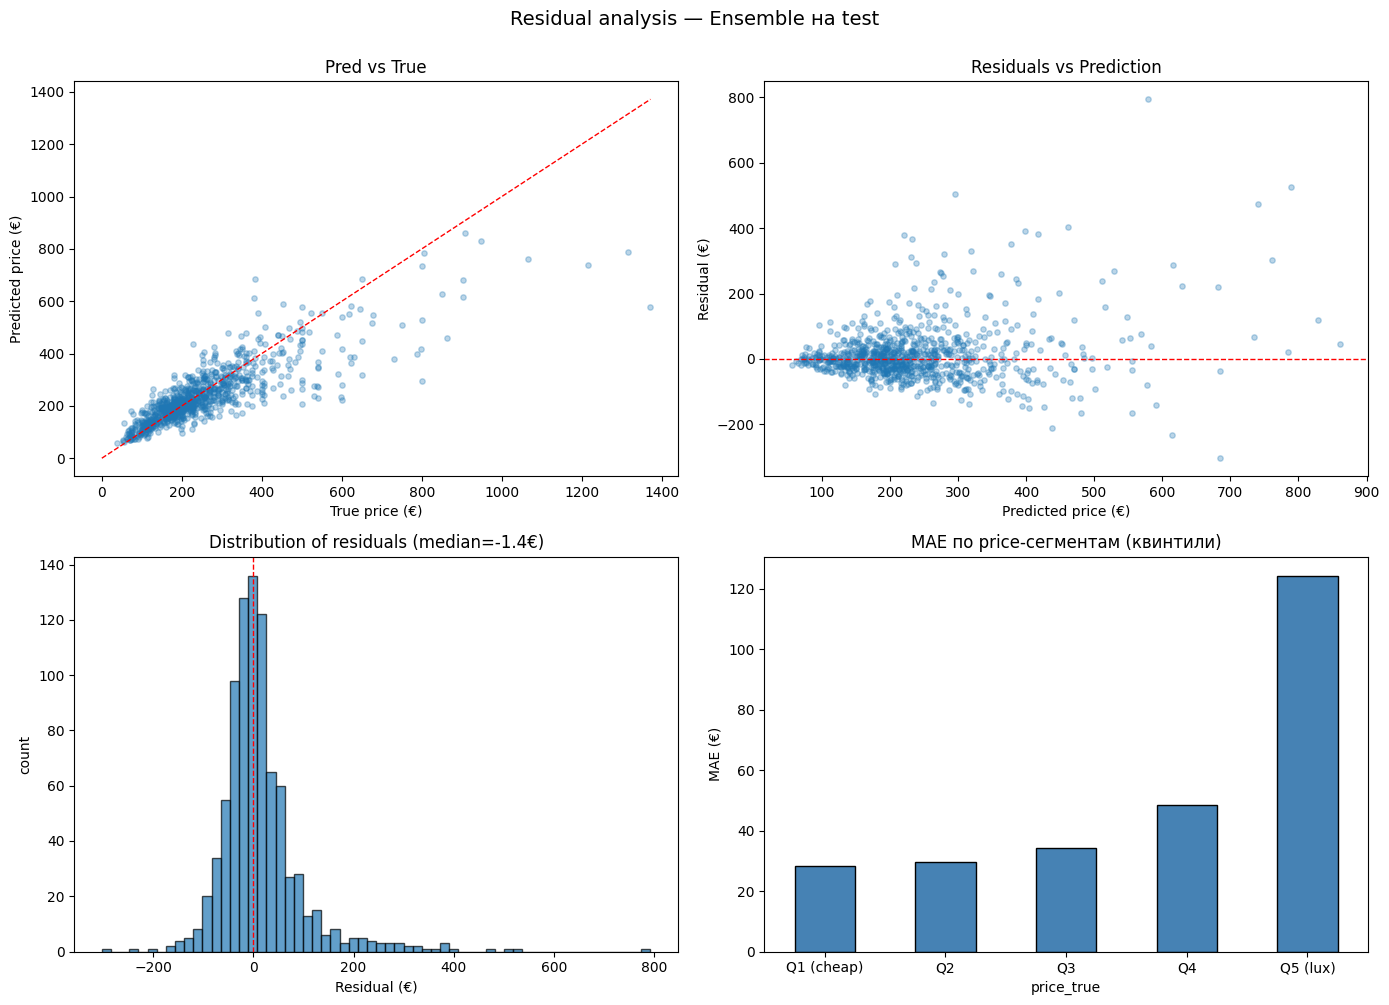


Топ-5 районов по MAE на test:
                           mean  count
neighbourhood_cleansed                
IJburg - Zeeburgereiland  72.40     16
Zuid                      64.50     65
Buitenveldert - Zuidas    60.37     11
Bos en Lommer             60.13     39
Centrum-Oost              59.33     87

NB: модель обучена на 4090 train + протестирована на 877 test rows (все с известной ценой (prie)). При инференсе на «новых» listing возможен selection bias.


In [22]:
# Residual analysis (анализ остатков): residual = факт − предсказание.
# Берём ensemble как финальный продукт, считаем на ОРИГИНАЛЬНОЙ шкале (евро).
y_true_eur = np.expm1(y_te.values)
y_pred_eur = np.expm1(preds_test["ens"]).clip(min=1)
resid_eur  = y_true_eur - y_pred_eur
diag = X_te.copy()
diag["price_true"] = y_true_eur
diag["price_pred"] = y_pred_eur
diag["residual"]   = resid_eur
diag["abs_err"]    = np.abs(resid_eur)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Pred vs True — диагональ = идеальная модель
ax = axes[0, 0]
ax.scatter(y_true_eur, y_pred_eur, alpha=0.3, s=15)
lo, hi = 0, max(y_true_eur.max(), y_pred_eur.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1)
ax.set(xlabel="True price (€)", ylabel="Predicted price (€)", title="Pred vs True")

# (2) Residuals vs prediction — должны быть «облаком» вокруг 0 (нет систематики)
ax = axes[0, 1]
ax.scatter(y_pred_eur, resid_eur, alpha=0.3, s=15)
ax.axhline(0, color="r", ls="--", lw=1)
ax.set(xlabel="Predicted price (€)", ylabel="Residual (€)", title="Residuals vs Prediction")

# (3) Распределение остатков (хотим симметричное вокруг 0, без длинного хвоста)
ax = axes[1, 0]
ax.hist(resid_eur, bins=60, edgecolor="black", alpha=0.7)
ax.axvline(0, color="r", ls="--", lw=1)
ax.set(xlabel="Residual (€)", ylabel="count",
       title=f"Distribution of residuals (median={np.median(resid_eur):+.1f}€)")

# (4) MAE по price-квинтилям — где модель ошибается больше всего
seg = pd.qcut(diag["price_true"], q=5, labels=["Q1 (cheap)", "Q2", "Q3", "Q4", "Q5 (lux)"])
seg_mae = diag.groupby(seg, observed=True)["abs_err"].mean()
ax = axes[1, 1]
seg_mae.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set(ylabel="MAE (€)", title="MAE по price-сегментам (квинтили)")
ax.tick_params(axis="x", rotation=0)
plt.suptitle("Residual analysis — Ensemble на test", fontsize=14, y=1.0)
plt.tight_layout(); plt.show()

# Текстовая сводка: топ-5 районов и room_type по MAE
print('\nТоп-5 районов по MAE на test:')
print(diag.groupby("neighbourhood_cleansed")["abs_err"]
      .agg(["mean", "count"]).sort_values("mean", ascending=False).head(5).round(2))

# Selection bias note: модель обучена только на listing с known price (price.notna()).
# В проде объявления без цены — отдельная подвыборка (новые/неактивные хосты), и метрики на ней
# могут быть хуже. Это ограничение всех price-моделей Airbnb-датасета.
print(f'\nNB: модель обучена на {len(y_tr)} train + протестирована на {len(y_te)} test rows '
      f"(все с известной ценой (price)). При инференсе на «новых» listing возможен selection bias.")

### Что показывают графики

- **Pred vs True** — большинство точек расположено близко к диагонали, значит модель в целом хорошо воспроизводит реальные цены. При этом для дорогих listings разброс заметно увеличивается — luxury-объекты предсказывать сложнее.

- **Residuals vs Prediction** — остатки распределены вокруг нуля без сильного систематического смещения, однако дисперсия ошибок растёт вместе с ценой (`heteroscedasticity`). Это типично для задач прогнозирования стоимости недвижимости и short-term rentals.

- **Distribution of residuals** — распределение остатков близко к симметричному, медиана residuals ≈ `-1.4€`, то есть выраженного bias в сторону переоценки или недооценки нет.

- **MAE по price-сегментам** — ошибка постепенно растёт от дешёвых listings к дорогим. Основной вклад в общий MAE даёт сегмент `Q5 (luxury)`, где цены наиболее нестабильны и зависят от факторов, отсутствующих в датасете.

- **MAE по районам** — самые высокие ошибки наблюдаются в районах `IJburg - Zeeburgereiland`, `Zuid` и `Buitenveldert - Zuidas`. Частично это связано с меньшим количеством наблюдений и более высокой вариативностью цен в premium-локациях.

## SHAP Explainability

- `shap.TreeExplainer` для CatBoost
- Global: summary plot (топ-20)
- Dependence plots: топ-10
- Local: 3–5 примеров (cheap / median / expensive / undervalued / overpriced)
- Force plot для одного prediction

In [23]:
# SHAP (SHapley Additive exPlanations) — теория Шапли из кооперативной теории игр.
# Для каждой строки даёт ВКЛАД каждого признака в предсказание (в единицах target = log_price).
# TreeExplainer — точный алгоритм для tree-based моделей (O(TLD²)).
# Берём tuned CatBoost — для деревьев SHAP-значения точные, а не приближённые

explainer = shap.TreeExplainer(cat_best)
shap_vals = explainer.shap_values(X_te)
print(f"shap_values shape: {shap_vals.shape}   (n_test × n_features)")
print(f"expected_value (E[ŷ] на train) в log-цене: {explainer.expected_value:.3f}"
      f"   → ~{np.expm1(explainer.expected_value):.1f}€")

shap_values shape: (877, 76)   (n_test × n_features)
expected_value (E[ŷ] на train) в log-цене: 5.415   → ~223.7€


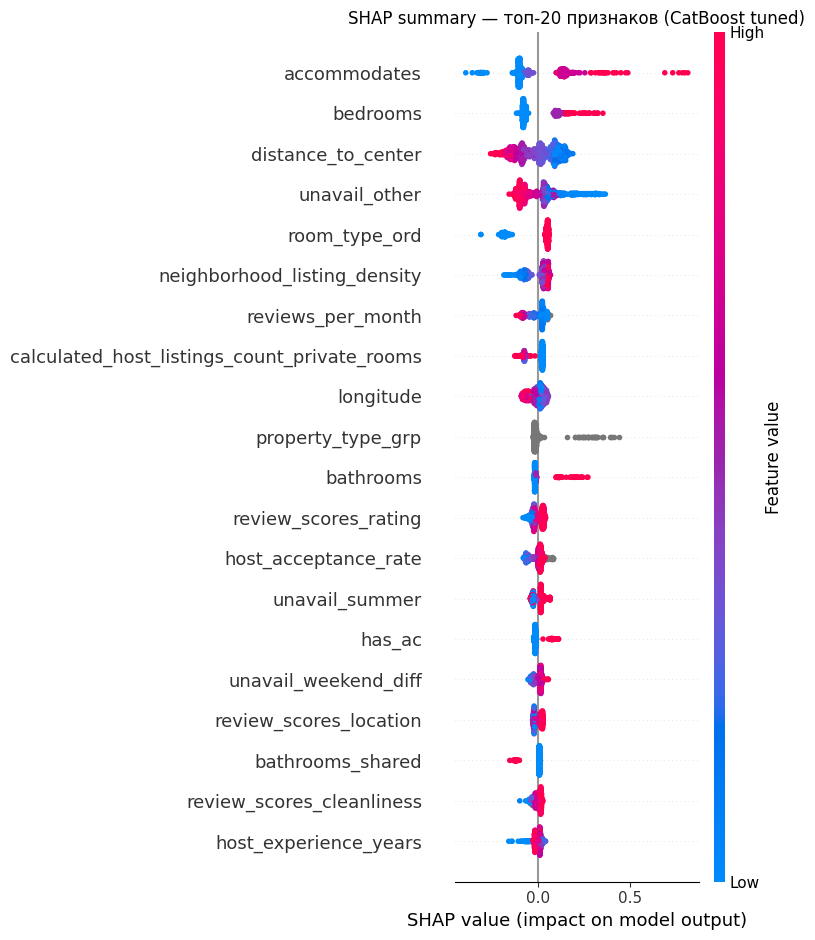


Топ-10 признаков по mean|SHAP|:
   1. accommodates                         mean|SHAP|=0.1249
   2. bedrooms                             mean|SHAP|=0.0934
   3. distance_to_center                   mean|SHAP|=0.0913
   4. unavail_other                        mean|SHAP|=0.0862
   5. room_type_ord                        mean|SHAP|=0.0830
   6. neighborhood_listing_density         mean|SHAP|=0.0532
   7. reviews_per_month                    mean|SHAP|=0.0409
   8. calculated_host_listings_count_private_rooms  mean|SHAP|=0.0377
   9. longitude                            mean|SHAP|=0.0300
  10. property_type_grp                    mean|SHAP|=0.0266


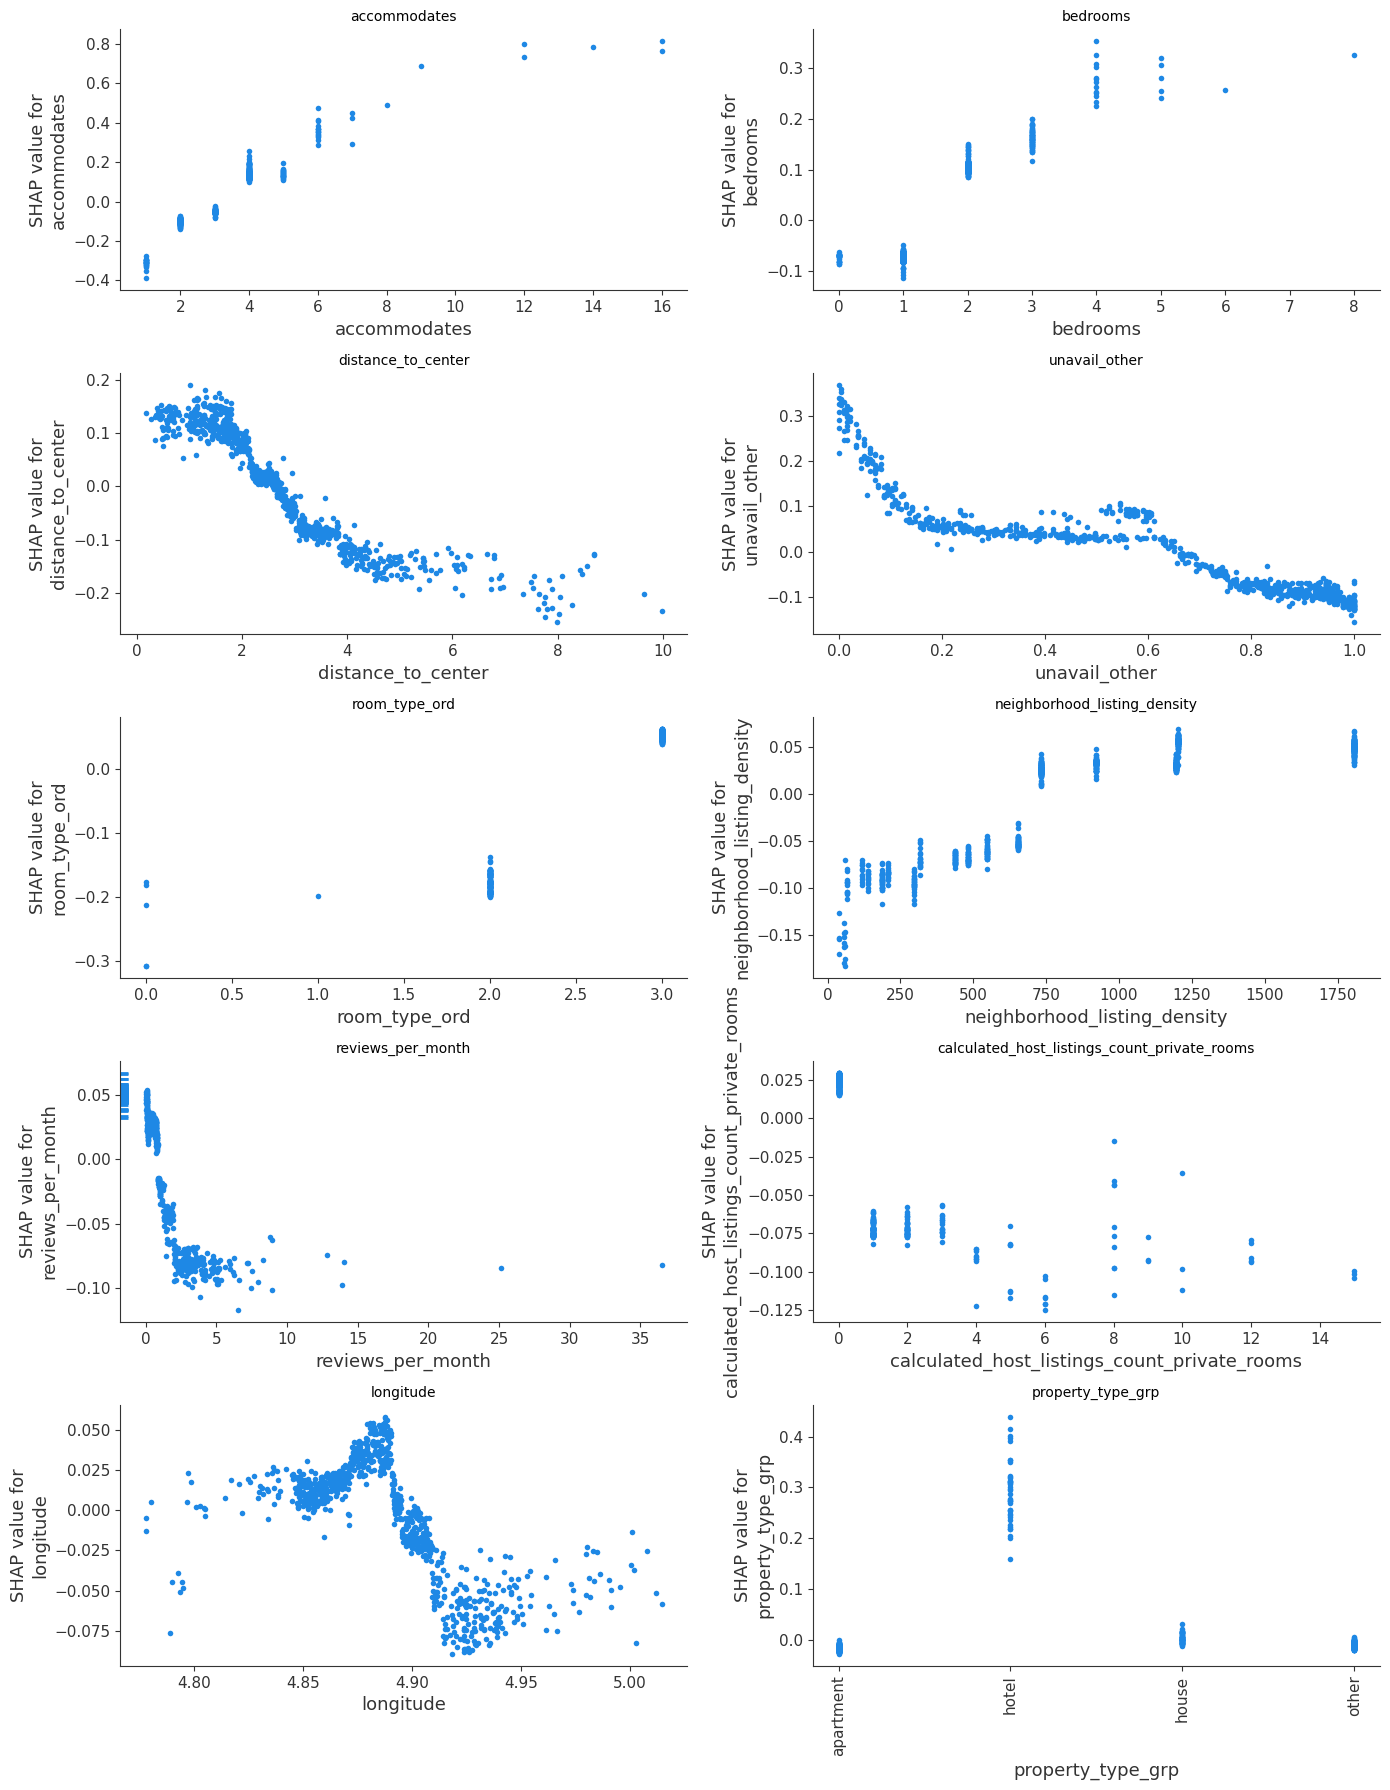

In [24]:
# Global SHAP — какие признаки в среднем самые важные (mean |SHAP|).
shap.summary_plot(shap_vals, X_te, max_display=20, show=False)
plt.title("SHAP summary — топ-20 признаков (CatBoost tuned)")
plt.tight_layout(); plt.show()

# Топ-10 признаков для dependence-плотов
mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=X_te.columns).sort_values(ascending=False)
top10 = mean_abs.head(10).index.tolist()
print('\nТоп-10 признаков по mean|SHAP|:')
for i, f in enumerate(top10, 1):
    print(f"  {i:2d}. {f:<35s}  mean|SHAP|={mean_abs[f]:.4f}")

# Dependence plots: как SHAP-вклад признака зависит от его значения.
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
for ax, feat in zip(axes.flat, top10):
    shap.dependence_plot(feat, shap_vals, X_te, ax=ax, show=False, interaction_index=None)
    ax.set_title(feat, fontsize=10)
plt.tight_layout(); plt.show()

In [27]:
# Local explanations — почему модель дала именно такой прогноз.
# 5 показательных listings: cheap / median / expensive + недо/переоценённые.
y_pred_eur_te = np.expm1(cat_best.predict(X_te)).clip(min=1)
y_true_eur_te = np.expm1(y_te.values)
err_eur       = y_true_eur_te - y_pred_eur_te

picks = {
    "cheap":       int(np.argsort(y_true_eur_te)[0]),
    "median":      int(np.argsort(np.abs(y_true_eur_te - np.median(y_true_eur_te)))[0]),
    "expensive":   int(np.argsort(y_true_eur_te)[-1]),
    "undervalued": int(np.argmax(err_eur)),   # модель ЗАНИЗИЛА — реально дороже
    "overpriced":  int(np.argmin(err_eur)),   # модель ЗАВЫСИЛА — реально дешевле
}
for label, i in picks.items():
    print(f'\n[{label.upper()}]  test row {i}')
    print(f"  true: {y_true_eur_te[i]:7.1f}€   pred: {y_pred_eur_te[i]:7.1f}€   err: {err_eur[i]:+.1f}€")
    contrib = pd.Series(shap_vals[i], index=X_te.columns).sort_values(key=abs, ascending=False).head(5)
    for f, v in contrib.items():
        arrow = "↑" if v > 0 else "↓"
        print(f"    {arrow} {f:<35s} SHAP={v:+.3f}   value={X_te.iloc[i][f]}")


[CHEAP]  test row 305
  true:    39.0€   pred:    58.5€   err: -19.5€
    ↓ accommodates                        SHAP=-0.299   value=1
    ↓ room_type_ord                       SHAP=-0.197   value=2
    ↓ distance_to_center                  SHAP=-0.169   value=8.07539797958339
    ↓ minimum_minimum_nights              SHAP=-0.112   value=30.0
    ↓ bathrooms_shared                    SHAP=-0.109   value=1.0

[MEDIAN]  test row 408
  true:   219.0€   pred:   295.0€   err: -76.0€
    ↑ accommodates                        SHAP=+0.132   value=4
    ↓ distance_to_center                  SHAP=-0.120   value=4.135077531201712
    ↓ unavail_other                       SHAP=-0.097   value=0.9234972677595629
    ↑ bedrooms                            SHAP=+0.097   value=2.0
    ↑ room_type_ord                       SHAP=+0.045   value=3

[EXPENSIVE]  test row 282
  true:  1372.0€   pred:   547.6€   err: +824.4€
    ↑ distance_to_center                  SHAP=+0.166   value=1.141053709100703
    ↑ 

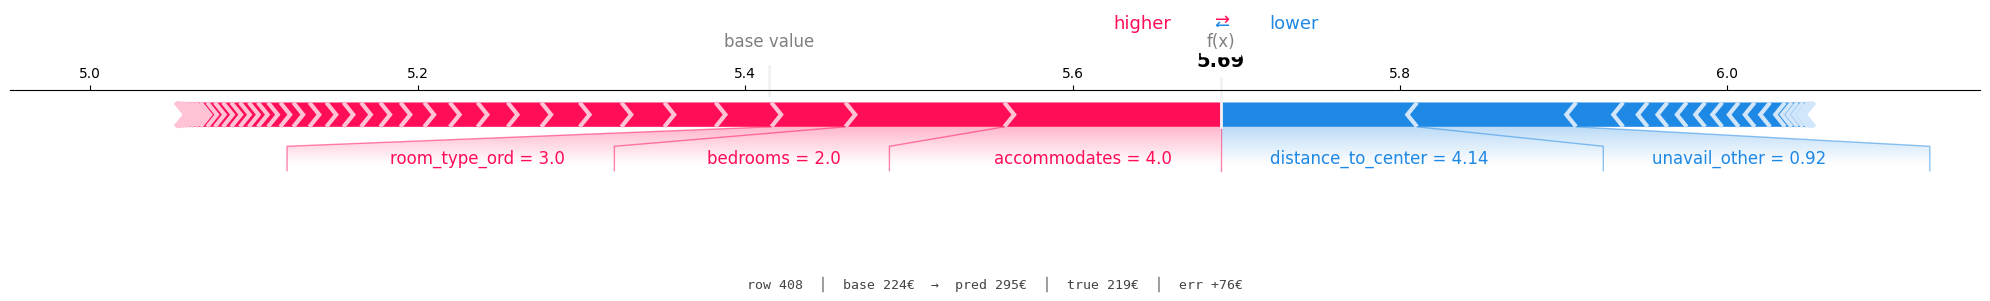

In [28]:
# Force plot для median listing
shap.initjs()
i = picks["median"]

pred_eur = float(np.expm1(cat_best.predict(X_te.iloc[[i]])[0]))
true_eur = float(np.expm1(y_te.iloc[i]))
base_eur = float(np.expm1(explainer.expected_value))

# Округляем числа — компактные подписи на баре
# ИСПРАВЛЕНИЕ: iloc[[i]] → DataFrame (сохраняет dtype каждой колонки),
# затем .iloc[0] обратно в Series для force_plot
num_cols    = X_te.select_dtypes(include="number").columns
row_display = X_te.iloc[[i]].copy()          # DataFrame, не Series
row_display[num_cols] = row_display[num_cols].round(2)
row_display = row_display.iloc[0]            # обратно в Series

shap.force_plot(
    explainer.expected_value,
    shap_vals[i],
    row_display,
    matplotlib=True,
    show=False,
    figsize=(20, 3),
    text_rotation=0,
)
fig = plt.gcf()
fig.text(
    0.5, -0.04,
    f"row {i}  │  base {base_eur:.0f}€  →  pred {pred_eur:.0f}€  │  true {true_eur:.0f}€  │  err {pred_eur - true_eur:+.0f}€",
    ha="center", va="top", fontsize=9.5, color="#444444", fontfamily="monospace",
)
plt.tight_layout()
plt.show()

### SHAP Explainability — выводы

SHAP-анализ показывает, какие признаки сильнее всего влияют на итоговую цену listing и в какую сторону они двигают prediction модели.

#### Global importance

Наиболее важные признаки для модели:
1. `accommodates`
2. `bedrooms`
3. `distance_to_center`
4. `unavail_other`
5. `room_type_ord`

Главный драйвер цены — вместимость жилья (`accommodates`) и количество спален (`bedrooms`): большие объекты почти всегда повышают prediction.

Также сильное влияние оказывает расположение:
- чем ближе объект к центру (`distance_to_center` меньше),
- тем выше SHAP contribution и итоговая цена.

Тип жилья (`room_type_ord`) тоже важен:
- entire home/apartment повышает prediction,
- private/shared room — снижает.

#### Dependence plots

Dependence plots показывают, что модель изучила понятные рыночные зависимости:

- `accommodates` и `bedrooms` дают почти монотонный рост цены;
- влияние `distance_to_center` нелинейно: особенно сильное удорожание происходит в пределах ~2–3 км от центра;
- высокая `neighborhood_listing_density` обычно связана с более дорогими районами;
- рост `reviews_per_month` после определённого уровня почти перестаёт влиять на цену;
- `unavail_other` работает как proxy спроса: менее доступные listings чаще оказываются дороже.

#### Local explanations

Локальные SHAP-примеры показывают, почему модель ошибается на отдельных объектах:

- дешёвые listings обычно получают отрицательные SHAP contribution из-за:
  - малого размера,
  - shared/private room,
  - удалённости от центра;

- дорогие объекты получают высокий positive SHAP от:
  - location,
  - large capacity,
  - большого числа amenities,
  - multiple bedrooms/bathrooms.

При этом extreme luxury listings модель часто недооценивает. Например, объект с реальной ценой `1372€` был предсказан как `548€`. Это говорит о том, что часть факторов luxury-сегмента отсутствует в данных (дизайн, интерьер, вид, брендовые apartments, premium photos и т.д.).

#### Общий вывод

SHAP показывает, что модель принимает решения логично и использует экономически интерпретируемые признаки. Основные драйверы цены соответствуют реальному рынку Airbnb:
- размер жилья,
- location,
- тип жилья,
- плотность и спрос в районе,
- качество и популярность listing.

## Save Models

- `models/catboost_pricing.cbm`
- `models/lightgbm_pricing.txt`
- `models/xgboost_pricing.json`
- `models/ensemble_weights.json`
- `models/shap_explainer.pkl`

In [29]:
# Сохраняем все артефакты —  для production-инференса (Streamlit/API).
cat_best.save_model(MODELS / "catboost_pricing.cbm")
lgb_best.booster_.save_model(MODELS / "lightgbm_pricing.txt")
xgb_best.save_model(MODELS / "xgboost_pricing.json")
with open(MODELS / "ensemble_weights.json", "w") as f:
    json.dump({"weights": weights, "models": ens_models}, f, indent=2)
with open(MODELS / "shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)
# Списочек категориальных колонок — нужен при инференсе для приведения dtype.
with open(MODELS / "cat_cols.json", "w") as f:
    json.dump(CAT_COLS, f, indent=2)
print(f"Сохранено в {MODELS}/")
for f in sorted(os.listdir(MODELS)):
    kb = os.path.getsize(MODELS / f) / 1024
    print(f"  {f:<35s} {kb:>10.1f} KB")

Сохранено в ../models/
  .gitkeep                                   0.0 KB
  best_params.json                           0.8 KB
  cat_cols.json                              0.1 KB
  catboost_pricing.cbm                     401.4 KB
  ensemble_weights.json                      0.2 KB
  kmeans_hosts.pkl                          21.1 KB
  lightgbm_pricing.txt                     190.4 KB
  recommender_nn.pkl                     19604.0 KB
  shap_explainer.pkl                      2980.6 KB
  xgboost_pricing.json                     892.5 KB


## Эксперимент: компактная модель (топ-20 фичей)

Ablation study (исследование путём отсечения) — обучаем те же 3 GBM с теми же best_params,
но только на топ-20 признаках по mean|SHAP|. Цель — проверить, насколько падает качество,
если выкинуть «хвост» из 56 фичей.

- топ-20 берём из `mean_abs` (вычислено вна CatBoost tuned)
- best_params **не меняем** (compare apples-to-apples; компактная модель потенциально может выиграть от ре-тюна)
- веса ensemble оставляем те же (1 / val_MAE на 76-фичной версии)
- сравниваем 4 модели: CatBoost / LightGBM / XGBoost / Ensemble — full vs lean


In [30]:
# Топ-20 фичей по mean|SHAP| (mean_abs посчитан на CatBoost tuned).
TOP_N = 20
top_feats = mean_abs.head(TOP_N).index.tolist()
print(f"Используем {TOP_N} признаков из {X_tr.shape[1]} ({TOP_N/X_tr.shape[1]:.0%}):")
for i, f in enumerate(top_feats, 1):
    print(f"  {i:2d}. {f:<40s} mean|SHAP|={mean_abs[f]:.4f}")

# Подмножества (subsets) для каждой библиотеки — берём те же 3 версии X (cat / lgb / xgb)
X_tr_20,  X_val_20,  X_te_20  = X_tr[top_feats],     X_val[top_feats],     X_te[top_feats]
X_tr_20l, X_val_20l, X_te_20l = X_tr_lgb[top_feats], X_val_lgb[top_feats], X_te_lgb[top_feats]
X_tr_20x, X_val_20x, X_te_20x = X_tr_xgb[top_feats], X_val_xgb[top_feats], X_te_xgb[top_feats]

# Категориальные среди топ-20 (нужны CatBoost.fit(cat_features=...))
CAT_COLS_20 = [c for c in CAT_COLS if c in top_feats]
print(f'\nКатегориальных в топ-20: {len(CAT_COLS_20)} → {CAT_COLS_20}')


Используем 20 признаков из 76 (26%):
   1. accommodates                             mean|SHAP|=0.1249
   2. bedrooms                                 mean|SHAP|=0.0934
   3. distance_to_center                       mean|SHAP|=0.0913
   4. unavail_other                            mean|SHAP|=0.0862
   5. room_type_ord                            mean|SHAP|=0.0830
   6. neighborhood_listing_density             mean|SHAP|=0.0532
   7. reviews_per_month                        mean|SHAP|=0.0409
   8. calculated_host_listings_count_private_rooms mean|SHAP|=0.0377
   9. longitude                                mean|SHAP|=0.0300
  10. property_type_grp                        mean|SHAP|=0.0266
  11. bathrooms                                mean|SHAP|=0.0260
  12. review_scores_rating                     mean|SHAP|=0.0256
  13. host_acceptance_rate                     mean|SHAP|=0.0251
  14. unavail_summer                           mean|SHAP|=0.0247
  15. has_ac                                   me

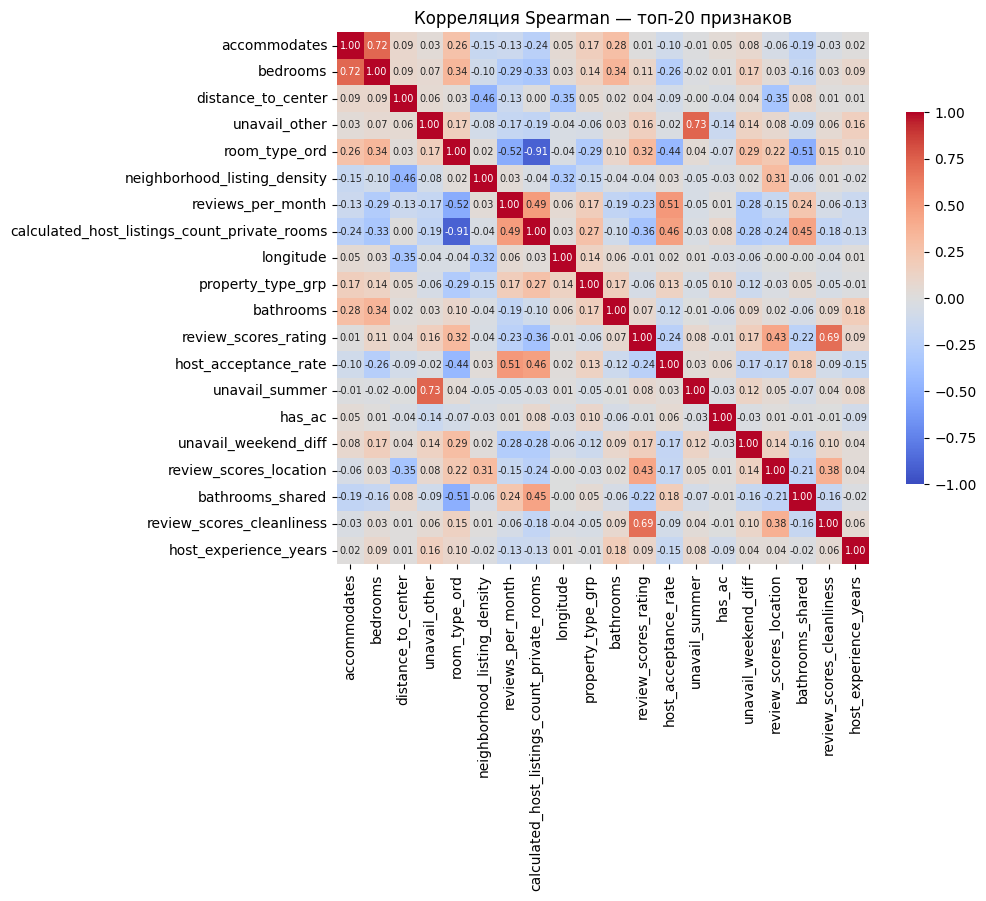


Пары с |r| > 0.6 (4 шт):
  room_type_ord                    ↔ calculated_host_listings_count_private_rooms r=-0.91
  unavail_other                    ↔ unavail_summer                   r=+0.73
  accommodates                     ↔ bedrooms                         r=+0.72
  review_scores_rating             ↔ review_scores_cleanliness        r=+0.69


In [31]:
# Корреляция Spearman среди топ-20 — устойчива к нелинейностям, работает и с порядковыми фичами.
# Категории кодируем как cat.codes, чтобы вся матрица была числовой.
df_corr = X_te_20.copy()
for c in CAT_COLS_20:
    df_corr[c] = df_corr[c].astype("category").cat.codes
corr = df_corr.corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Корреляция Spearman — топ-20 признаков")
plt.tight_layout(); plt.show()

# Пары с |r| > 0.6 — потенциальные «дубликаты сигнала» (модели от них не выигрывают).
pairs = (corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
             .stack().rename("r").reset_index())
strong = pairs[pairs["r"].abs() > 0.6].sort_values("r", key=abs, ascending=False)
if len(strong):
    print(f'\nПары с |r| > 0.6 ({len(strong)} шт):')
    for _, row in strong.iterrows():
        print(f'  {row["level_0"]:<32s} ↔ {row["level_1"]:<32s} r={row["r"]:+.2f}')
else:
    print('\nСильно скоррелированных пар (|r| > 0.6) среди топ-20 нет.')


In [32]:
# Refit 3 GBM с теми же best_params (от Optuna) — но только на топ-20 фичах.

# CatBoost
cat_20 = cb.CatBoostRegressor(**{**cat_params, **cb_study.best_params})
t0 = time.time()
cat_20.fit(X_tr_20, y_tr, eval_set=(X_val_20, y_val), cat_features=CAT_COLS_20)
cat_20_time = time.time() - t0
cat_20_val, cat_20_test = cat_20.predict(X_val_20), cat_20.predict(X_te_20)
report_model("CatBoost (top-20)", cat_20_time, cat_params["task_type"],
             y_val, cat_20_val, y_te, cat_20_test,
             best_iter=cat_20.get_best_iteration())

# LightGBM
lgb_20 = lgb.LGBMRegressor(**{**lgb_base, **lgb_study.best_params})
t0 = time.time()
lgb_20.fit(X_tr_20l, y_tr, eval_set=[(X_val_20l, y_val)], eval_metric="mae",
           callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_20_time = time.time() - t0
lgb_20_val, lgb_20_test = lgb_20.predict(X_val_20l), lgb_20.predict(X_te_20l)
report_model("LightGBM (top-20)", lgb_20_time, "CPU",
             y_val, lgb_20_val, y_te, lgb_20_test,
             best_iter=lgb_20.best_iteration_)

# XGBoost
xgb_20 = xgb.XGBRegressor(**{**xgb_params, **xgb_study.best_params})
t0 = time.time()
xgb_20.fit(X_tr_20x, y_tr, eval_set=[(X_val_20x, y_val)], verbose=False)
xgb_20_time = time.time() - t0
xgb_20_val, xgb_20_test = xgb_20.predict(X_val_20x), xgb_20.predict(X_te_20x)
report_model("XGBoost (top-20)", xgb_20_time, xgb_params["device"],
             y_val, xgb_20_val, y_te, xgb_20_test,
             best_iter=xgb_20.best_iteration)

# Словари предсказаний компактной версии — для ансамбля и сводной таблицы.
preds_val_20  = {"cat": cat_20_val,  "lgb": lgb_20_val,  "xgb": xgb_20_val}
preds_test_20 = {"cat": cat_20_test, "lgb": lgb_20_test, "xgb": xgb_20_test}


Default metric period is 5 because MAE is/are not implemented for GPU



[CatBoost (top-20)]   fit: 12.72s   device: GPU   best_iter: 333
              MAE      RMSE    RMSLE       R²
  val       58.70     94.98    0.278    0.648
  test      55.92     93.35    0.284    0.631

[LightGBM (top-20)]   fit: 0.08s   device: CPU   best_iter: 122
              MAE      RMSE    RMSLE       R²
  val       58.58     93.54    0.276    0.659
  test      56.00     91.97    0.280    0.641

[XGBoost (top-20)]   fit: 2.44s   device: cuda   best_iter: 399
              MAE      RMSE    RMSLE       R²
  val       58.52     93.87    0.277    0.657
  test      55.39     92.23    0.279    0.639


In [33]:
# Ensemble на топ-20 с ТЕМИ ЖЕ весами, что и для 76-фичной версии (compare apples-to-apples).
ens_pred_val_20  = sum(weights[m] * preds_val_20[m]  for m in ens_models)
ens_pred_test_20 = sum(weights[m] * preds_test_20[m] for m in ens_models)
report_model("Ensemble (top-20)", 0.0, "—",
             y_val, ens_pred_val_20, y_te, ens_pred_test_20)
preds_val_20["ens"]  = ens_pred_val_20
preds_test_20["ens"] = ens_pred_test_20

# Sanity-check: ансамбль должен бить лучшую single-модель на топ-20.
single_best_20 = min(ens_models, key=lambda m: metrics(y_te, preds_test_20[m])["MAE"])
ens_mae_20  = metrics(y_te, ens_pred_test_20)["MAE"]
best_mae_20 = metrics(y_te, preds_test_20[single_best_20])["MAE"]
verdict = "✔ лучше" if ens_mae_20 < best_mae_20 else "✘ хуже"
print(f'\nEnsemble (top-20) test MAE: {ens_mae_20:.2f}€   vs   {single_best_20.upper()}: {best_mae_20:.2f}€'
      f"   (Δ {ens_mae_20-best_mae_20:+.2f}€ — {verdict})")



[Ensemble (top-20)]   fit: 0.00s   device: —
              MAE      RMSE    RMSLE       R²
  val       58.04     93.53    0.274    0.659
  test      55.01     91.69    0.278    0.643

Ensemble (top-20) test MAE: 55.01€   vs   XGB: 55.39€   (Δ -0.38€ — ✔ лучше)


In [34]:
# Сводная таблица: full (76 фичей) vs lean (20 фичей) — для всех 4 моделей на test.
# Δ = lean − full   (положительное = просадка, отрицательное = улучшение).
compare_meta = [
    ("CatBoost",  "cat"),
    ("LightGBM",  "lgb"),
    ("XGBoost",   "xgb"),
    ("Ensemble",  "ens"),
]
rows = {}
for name, k in compare_meta:
    f = metrics(y_te, preds_test[k])
    l = metrics(y_te, preds_test_20[k])
    rows[name] = {
        ("full-76", "MAE"):  f["MAE"],  ("full-76", "RMSE"): f["RMSE"], ("full-76", "R²"): f["R2"],
        ("lean-20", "MAE"):  l["MAE"],  ("lean-20", "RMSE"): l["RMSE"], ("lean-20", "R²"): l["R2"],
        ("Δ lean-full", "MAE"):  l["MAE"]  - f["MAE"],
        ("Δ lean-full", "RMSE"): l["RMSE"] - f["RMSE"],
        ("Δ lean-full", "R²"):   l["R2"]   - f["R2"],
    }
compare = pd.DataFrame(rows).T
col_order = ([("full-76", m) for m in ["MAE", "RMSE", "R²"]] +
             [("lean-20", m) for m in ["MAE", "RMSE", "R²"]] +
             [("Δ lean-full", m) for m in ["MAE", "RMSE", "R²"]])
compare = compare[col_order]

fmt = {c: "{:.2f}" for c in col_order if c[1] in ("MAE", "RMSE")}
fmt.update({c: "{:.3f}" for c in col_order if c[1] == "R²"})
fmt.update({("Δ lean-full", m): "{:+.2f}" for m in ("MAE", "RMSE")})
fmt[("Δ lean-full", "R²")] = "{:+.3f}"
display(compare.style.format(fmt).set_caption("Full (76 фичей) vs Lean (20 фичей) — test"))

# Бонус: корреляция предсказаний full vs lean — насколько модели «согласны» между собой.
print('\nКорреляция предсказаний full vs lean (test, Pearson):')
for name, k in compare_meta:
    r = np.corrcoef(preds_test[k], preds_test_20[k])[0, 1]
    print(f"  {name:<10s} r = {r:.4f}")



Корреляция предсказаний full vs lean (test, Pearson):
  CatBoost   r = 0.9774
  LightGBM   r = 0.9729
  XGBoost    r = 0.9771
  Ensemble   r = 0.9816


### Эксперимент с компактной моделью (top-20 features)

Ablation study показывает, что большая часть predictive signal действительно сосредоточена в небольшом числе признаков. Использование только `20` фичей из `76` (≈26% всех признаков) приводит лишь к умеренному ухудшению качества.

Лучший результат среди compact-моделей показал `Ensemble (top-20)`:
- `MAE = 55.01€`
- `R² = 0.643`

По сравнению с full-моделью (`MAE = 52.96€`, `R² = 0.678`) ухудшение составляет примерно:
- `+2€ MAE`
- `-0.03–0.04 R²`

Это относительно небольшая потеря качества с учётом того, что было удалено более `70%` признаков.

#### Что показывают результаты

- Все три GBM ведут себя очень похоже: качество падает умеренно, но не критично;
- Предсказания full и lean моделей почти совпадают (`Pearson r ≈ 0.97–0.98`);
- Основной signal действительно содержится в:
  - размере жилья,
  - location,
  - типе жилья,
  - спросе/availability,
  - review-related features.

#### Корреляции признаков

Heatmap показывает несколько сильных зависимостей между top features:
- `accommodates ↔ bedrooms` (`r=0.72`)
- `room_type_ord ↔ calculated_host_listings_count_private_rooms` (`r=-0.91`)
- `unavail_other ↔ unavail_summer` (`r=0.73`)

Это означает, что часть признаков несёт пересекающуюся информацию, поэтому удаление «хвоста» фичей не разрушает качество модели.

#### Практический вывод

Компактная модель:
- обучается быстрее,
- проще для интерпретации,
- требует меньше feature engineering,
- сохраняет большую часть качества full-модели.

При этом full-версия всё же стабильно лучше по всем метрикам, поэтому именно она остаётся финальной production-моделью.
